# Finsler Flow Matching on the Pancreas

scVelo endocrinogenesis (Bastidas-Ponce et al., 2019), 3696 cells. `latent_time` is cut
into three equal-quantile marginals, the middle one is withheld, and every arm is scored
at $t = 1/2$ against it. Four spaces: $d = 10, 20, 50$ are nested PCA prefixes, $d = 2$ is
the UMAP chart z-scored per axis.


In [1]:
%matplotlib inline
import matplotlib
_NB_BACKEND = matplotlib.get_backend()

import pathlib
import sys

_here = pathlib.Path.cwd().resolve()
PUBLIC = next((p for p in (_here, *_here.parents)
               if (p / "scripts").is_dir() and (p / "notebooks").is_dir()), None)
assert PUBLIC is not None, "run this from inside the repo's public/ tree"
sys.path.insert(0, str(PUBLIC))

import time

import numpy as np
import pandas as pd
import torch

from scripts.experiments.pancreas.datasets import (DIMS, HOLDOUT_BIN, TRAIN_BINS,
                                                   TUNED_DIMS, UMAP_DIM,
                                                   build_training_set,
                                                   holdout_moment_fidelity, load_cloud,
                                                   split_holdout)
from scripts.experiments.sheet.datasets import GAP, SOURCE, TARGET
from scripts.experiments.sheet.paper_focus import (PATHB_NAME, QUAL_DET, QUAL_NOISY,
                                                   two_line)
from scripts.core.arms import HParams, run_arm
from scripts.core.metrics import (distribution_metrics, mean_floor, traj_slice,
                                  wasserstein)
from scripts.core.paths import figure_dir, rel
import scripts.method
from scripts.method import (FWFactory, Run, cuda_warm_up, finsler_w2, moments_from,
                            path_a, path_b, pct_change, results_table, seed_frame,
                            sigma_for)
from scripts.method import figures as nbfig

matplotlib.use(_NB_BACKEND)
import matplotlib.pyplot as plt

REG = nbfig.PAPER_REGIONS
pd.set_option("display.width", 220)
print(f"torch {torch.__version__}   cuda {torch.cuda.is_available()}")


torch 2.4.0+cu124   cuda True


## Constants and the tuned point


In [2]:
cfg = Run.from_env()

import os
DIMS_RUN = tuple(int(d) for d in os.environ["NB_DIMS"].split(",")) if os.environ.get(
    "NB_DIMS") else DIMS

TUNED = {
    2: {
        'ffm': {'rho_mult': 1.000000e-01, 'lam_mult': 1.000000e-01},
        'mfm_land': {'land_rho': 3.160000e-04},
        'curly': {'curly_alpha': 1.000000e-01},
        'cfm': {},
        'pathb': {'width_mult': 1.000000e+00},
    },
    10: {
        'ffm': {'rho_mult': 3.000000e-03, 'lam_mult': 3.000000e-01},
        'mfm_land': {'land_rho': 3.160000e-03},
        'curly': {'curly_alpha': 1.000000e-01},
        'cfm': {},
        'pathb': {'width_mult': 1.000000e+00},
    },
    20: {
        'ffm': {'rho_mult': 1.000000e-03, 'lam_mult': 1.000000e+00},
        'mfm_land': {'land_rho': 3.160000e-03},
        'curly': {'curly_alpha': 1.000000e+00},
        'cfm': {},
        'pathb': {'width_mult': 1.000000e-01},
    },
    50: {
        'ffm': {'rho_mult': 1.000000e-03, 'lam_mult': 1.000000e-02},
        'mfm_land': {'land_rho': 1.000000e-04},
        'curly': {'curly_alpha': 1.000000e+00},
        'cfm': {},
        'pathb': {'width_mult': 1.000000e-02},
    },
}

FFM_DET = f"{PATHB_NAME} (ours), {QUAL_DET}"
FFM_SDE = f"{PATHB_NAME} (ours), {QUAL_NOISY}"
BASELINES = {"OT-CFM": "cfm", "MFM / LAND": "mfm_land", "Curly-FM": "curly"}
TUNE_KEY = {**{k: v for k, v in BASELINES.items()}, FFM_DET: "ffm", FFM_SDE: "pathb"}
REPORTED = [FFM_DET, FFM_SDE, *BASELINES]
BASE_N_STEPS = 102

assert tuple(TUNED) == tuple(TUNED_DIMS)
print(cfg)
print(f"d {DIMS_RUN}   arms {len(REPORTED)}   "
      f"runs {len(DIMS_RUN) * len(REPORTED) * len(cfg.seeds)}")


device cuda   seeds (0, 1, 2)   smoke False   iters 2500/1500/1500
d (2, 10, 20, 50)   arms 5   runs 60


## The cloud, the three marginals, and $P$


In [3]:
CLOUDS = {d: load_cloud(d) for d in DIMS_RUN}
TSETS  = {d: build_training_set(CLOUDS[d]) for d in DIMS_RUN}
TENS   = {}
for d in DIMS_RUN:
    ts = TSETS[d]
    X_t = cfg.tensor(np.asarray(ts.X, dtype=np.float64))
    TENS[d] = (X_t[torch.as_tensor(ts.p0, device=cfg.device)],
               X_t[torch.as_tensor(ts.p1, device=cfg.device)])

_c = CLOUDS[DIMS_RUN[0]]
_edges = _c.diag["quantile_edges"]
print(f"{len(_c.X)} cells   cut {_edges[1]:.3f} / {_edges[2]:.3f}   {_c.diag['bin_counts']}")
for b in (TRAIN_BINS[0], HOLDOUT_BIN, TRAIN_BINS[1]):
    lab = _c.celltype[_c.marginal(b)]
    top = pd.Series(lab).value_counts().head(3)
    print(f"  marginal {b}{' (withheld)' if b == HOLDOUT_BIN else '':<12s}{len(lab):>6}   "
          + "  ".join(f"{k} {v}" for k, v in top.items()))

_val, _test = split_holdout(_c)
print(f"\nwithheld {len(_val)} val / {len(_test)} test   "
      f"train {len(TSETS[DIMS_RUN[0]].idx)}\n")

print(f"{'d':>4}{'train':>8}{'P nnz':>9}{'asymmetry':>12}{'cos(J, v)':>12}"
      f"{'|v| median':>13}")
for d in DIMS_RUN:
    g = TSETS[d].diag
    print(f"{d:>4}{g['n_train']:>8}{TSETS[d].P.nnz:>9}{g['P_asymmetry']:>12.3f}"
          f"{g['cos_J_velocity']:>12.3f}{CLOUDS[d].diag['velocity_norm_median']:>13.4f}")


[scvelo_data] loading cache data/pancreas_cache/pancreas_d50_vw0.8_dynamical.npz
[scvelo_data] loading cache data/pancreas_cache/pancreas_d50_vw0.8_dynamical.npz
[scvelo_data] loading cache data/pancreas_cache/pancreas_d50_vw0.8_dynamical.npz
[scvelo_data] loading cache data/pancreas_cache/pancreas_d50_vw0.8_dynamical.npz


3696 cells   cut 0.294 / 0.816   [1232, 1232, 1232]
  marginal 0              1232   Ductal 916  Ngn3 low EP 259  Ngn3 high EP 57
  marginal 1 (withheld)   1232   Ngn3 high EP 585  Pre-endocrine 543  Beta 57
  marginal 2              1232   Beta 534  Alpha 470  Epsilon 110

withheld 120 val / 1112 test   train 2464

   d   train    P nnz   asymmetry   cos(J, v)   |v| median
   2    2464    39424       0.932       0.943       0.0147
  10    2464    39424       0.840       0.641       3.5180
  20    2464    39424       0.742       0.420       4.0183
  50    2464    39424       0.679       0.209       5.3574


In [4]:
MOM, FW, METRIC, SIGMA = {}, {}, {}, {}
for d in DIMS_RUN:
    X = np.asarray(TSETS[d].X, dtype=np.float64)
    b0_pts, D_pts = moments_from(TSETS[d].P, X)
    pt = TUNED[d]["ffm"]
    MOM[d] = (b0_pts, D_pts)
    FW[d] = FWFactory(X, D_pts, b0_pts, cfg,
                      rho_mult=pt["rho_mult"], lam_mult=pt["lam_mult"])
    METRIC[d] = FW[d].base
    SIGMA[d] = sigma_for(METRIC[d], TUNED[d]["pathb"]["width_mult"])


## $b_0$, drawn in UMAP


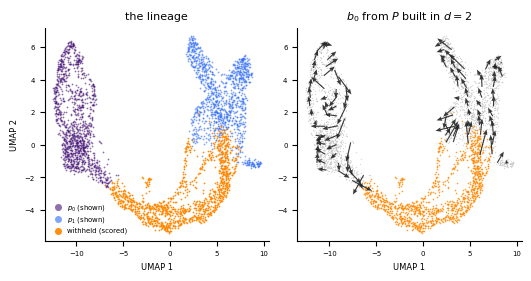

In [5]:
_c = CLOUDS[DIMS_RUN[0]]
U = _c.umap
_lo, _hi = U.min(axis=0), U.max(axis=0)
_pad = 0.04 * (_hi - _lo)
_d0 = DIMS_RUN[0]

fig, axes = plt.subplots(1, 2, figsize=(5.2, 2.7), constrained_layout=True)

for b, colour, lab in ((TRAIN_BINS[0], REG[SOURCE], "$p_0$ (shown)"),
                       (TRAIN_BINS[1], REG[TARGET], "$p_1$ (shown)"),
                       (HOLDOUT_BIN,   REG[GAP],    "withheld (scored)")):
    m = _c.marginal(b)
    axes[0].scatter(U[m, 0], U[m, 1], s=1.6, lw=0, c=colour, label=lab,
                    alpha=0.95 if b == HOLDOUT_BIN else 0.6)
axes[0].set_title("the lineage", fontsize=cfg.fs_heading)
axes[0].set_ylabel("UMAP 2", fontsize=cfg.fs_legend + 1)
axes[0].legend(fontsize=cfg.fs_legend, loc="best", frameon=False, markerscale=4,
               handletextpad=0.3, labelspacing=0.35)

_ts = TSETS[_d0]
_Y = U[_ts.idx]
axes[1].scatter(_Y[:, 0], _Y[:, 1], s=1.0, lw=0, c=nbfig.FAINT, alpha=0.5)
axes[1].scatter(U[_c.target, 0], U[_c.target, 1], s=1.4, lw=0, c=REG[GAP], alpha=0.8)
nbfig.flux_quiver(axes[1], _Y, _ts.P @ _Y - _Y, nu=16, nw=16)
axes[1].set_title(rf"$b_0$ from $P$ built in $d = {_d0}$", fontsize=cfg.fs_heading)

for ax in axes:
    ax.set_xlim(_lo[0] - _pad[0], _hi[0] + _pad[0])
    ax.set_ylim(_lo[1] - _pad[1], _hi[1] + _pad[1])
    ax.set_xlabel("UMAP 1", fontsize=cfg.fs_legend + 1)
    ax.tick_params(labelsize=cfg.fs_legend)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
plt.show()


## The runs


In [6]:
def _nearest(Y, pool_X, chunk=1024):
    pool_sq = (pool_X ** 2).sum(axis=1)
    out = [(pool_sq - 2.0 * Y[s:s + chunk] @ pool_X.T).argmin(axis=1)
           for s in range(0, len(Y), chunk)]
    return np.concatenate(out) if out else np.zeros(0, dtype=np.int64)


class Scorer:

    def __init__(self, cloud, n_draw, seed=0):
        self.cloud = cloud
        self.mid = cloud.X[cloud.target_test]
        self.end = cloud.X[cloud.marginal(TRAIN_BINS[1])]

        _dm = lambda a, b, k: distribution_metrics(a, b, seed=k)
        self.floors = {
            "intermediate": mean_floor(self.mid, n_draw, _dm, seed),
            "endpoint": mean_floor(self.end, n_draw, _dm, seed),
        }

    def __call__(self, traj, seed=0):
        return {"intermediate": distribution_metrics(traj_slice(traj, 0.5), self.mid,
                                                     seed=seed),
                "endpoint": distribution_metrics(traj_slice(traj, 1.0), self.end,
                                                 seed=seed),
                "floors": self.floors}


def run_baseline(label, dim, seed):
    hp = HParams(**cfg.arm_kw, **TUNED[dim][BASELINES[label]])
    res = run_arm(BASELINES[label], TSETS[dim], hp, seed, cfg.device, cfg.dtype,
                  n_steps=BASE_N_STEPS)
    return {"v_net": res.v_net, "sigma": 0.0,
            "traj": np.asarray(res.traj, dtype=np.float64), "ot": res.diag}


cuda_warm_up(METRIC[DIMS_RUN[0]], *TENS[DIMS_RUN[0]], cfg)

SCORE = {d: Scorer(CLOUDS[d], len(TENS[d][0])) for d in DIMS_RUN}
RUNS = {d: {} for d in DIMS_RUN}
TIMES = {d: {} for d in DIMS_RUN}
for d in DIMS_RUN:
    X0_t, X1_t = TENS[d]
    print(f"===== d = {d} =====")
    for seed in cfg.seeds:
        t0 = time.time()
        det = path_a(METRIC[d], X0_t, X1_t, seed, cfg)
        TIMES[d][(FFM_DET, seed)] = time.time() - t0
        det["sigma"] = 0.0
        det["metrics"] = SCORE[d](det["traj"])
        RUNS[d][(FFM_DET, seed)] = det
        t0 = time.time()
        noisy = path_b(METRIC[d], det["phi"], det["coupler"], X0_t, SIGMA[d], seed, cfg)
        TIMES[d][(FFM_SDE, seed)] = time.time() - t0
        noisy["metrics"] = SCORE[d](noisy["traj"])
        RUNS[d][(FFM_SDE, seed)] = noisy
        print(f"  FFM {seed}   {det['metrics']['intermediate']['W2']:.4f}"
              f" / {noisy['metrics']['intermediate']['W2']:.4f}"
              f"   ({TIMES[d][(FFM_DET, seed)]:.0f}s + {TIMES[d][(FFM_SDE, seed)]:.0f}s)")
    for label in BASELINES:
        for seed in cfg.seeds:
            t0 = time.time()
            out = run_baseline(label, d, seed)
            TIMES[d][(label, seed)] = time.time() - t0
            out["metrics"] = SCORE[d](out["traj"])
            RUNS[d][(label, seed)] = out
            print(f"  {label:12s} {seed}   "
                  f"{out['metrics']['intermediate']['W2']:.4f}   "
                  f"({TIMES[d][(label, seed)]:.0f}s)")


===== d = 2 =====


  FFM 0   1.6496 / 1.6860   (26s + 15s)


  FFM 1   1.6871 / 1.6642   (26s + 15s)


  FFM 2   1.6709 / 1.7369   (26s + 15s)
    [cfm]    iter     0  L_CFM = 2.762035


    [cfm]    iter   250  L_CFM = 0.169895


...

    [phase2] iter  1499  L_CFM = 2.091249


  MFM / LAND   2   12.9720   (254s)


  Curly-FM     0   13.5475   (444s)


  Curly-FM     1   13.2261   (445s)


  Curly-FM     2   13.2406   (445s)


## The table


In [7]:
COLUMNS = dict(scripts.method.BASE_COLUMNS)

for d in DIMS_RUN:
    print(f"\n===== d = {d}   {len(cfg.seeds)} seed(s)   {len(SCORE[d].mid)} withheld "
          f"cells   sigma {SIGMA[d]:.4f}")
    print(results_table(RUNS[d], REPORTED, cfg.seeds, COLUMNS,
                        floors=RUNS[d][(FFM_DET, cfg.seeds[0])]["metrics"]["floors"]
                        ).to_string())
    _mean = lambda nm, c: seed_frame(RUNS[d], nm, cfg.seeds, COLUMNS)[c].mean()
    best_base = min(BASELINES, key=lambda b: _mean(b, "mid W2"))
    print(f"  vs {best_base}   " + "   ".join(
        f"{nm.split(',')[-1].strip()} mid W2 "
        f"{pct_change(RUNS[d], best_base, nm, cfg.seeds, COLUMNS['mid W2']):+.1f}%"
        for nm in (FFM_DET, FFM_SDE)))

print("\n\nmid W2")
print(pd.DataFrame({d: {nm: seed_frame(RUNS[d], nm, cfg.seeds, COLUMNS)["mid W2"].mean()
                        for nm in REPORTED}
                    | {"sampling floor": SCORE[d].floors["intermediate"]["W2"]}
                    for d in DIMS_RUN}).to_string(float_format="%.4f"))



===== d = 2   3 seed(s)   1112 withheld cells   sigma 0.7172
                                    mid W2           end W2
FFM (ours), deterministic  1.6692 ± 0.0154  0.3283 ± 0.1293
FFM (ours), with noise     1.6957 ± 0.0305  0.2272 ± 0.0239
OT-CFM                     1.8062 ± 0.0197  0.1740 ± 0.0338
MFM / LAND                 1.4682 ± 0.0128  0.3769 ± 0.0346
Curly-FM                   0.9773 ± 0.1311  0.2581 ± 0.0371
sampling floor                      0.1113           0.1022
  vs Curly-FM   deterministic mid W2 +70.8%   with noise mid W2 +73.5%

===== d = 10   3 seed(s)   1112 withheld cells   sigma 4.2393
                                     mid W2            end W2
FFM (ours), deterministic  10.6505 ± 0.5441   4.0219 ± 0.1957
FFM (ours), with noise     10.4526 ± 0.4170   4.0360 ± 0.1983
OT-CFM                     11.7563 ± 0.0596   3.2672 ± 0.2015
MFM / LAND                 11.5355 ± 0.0504  11.0395 ± 0.4705
Curly-FM                   11.8655 ± 0.3553   4.6942 ± 0.5557
sampling flo

## $W_2$ between $t = 1/3$ and $t = 2/3$

In [ ]:
TS_CURVE = tuple(round(v, 3) for v in np.linspace(1.0 / 3.0, 2.0 / 3.0, 11))
sd_of = lambda v: float(np.std(v, ddof=1)) if len(v) > 1 else 0.0

pm = lambda v: f"{v.mean():.4f} \u00b1 {v.std(ddof=0):.4f}"

W2_SEEDS, W2_CURVE = {}, {}
for d in DIMS_RUN:
    _ref = SCORE[d].mid
    W2_SEEDS[d] = {t: {nm: np.array([wasserstein(traj_slice(RUNS[d][(nm, s)]["traj"], t),
                                                 _ref, seed=s) for s in cfg.seeds])
                       for nm in REPORTED} for t in TS_CURVE}
    W2_CURVE[d] = pd.DataFrame({t: {nm: float(v.mean()) for nm, v in c.items()}
                                for t, c in W2_SEEDS[d].items()})
    _f = pd.DataFrame({t: {nm: pm(v) for nm, v in c.items()}
                       for t, c in W2_SEEDS[d].items()})
    _f["argmin t"] = [f"{TS_CURVE[int(np.argmin(r))]:.3f}"
                      for r in W2_CURVE[d].loc[_f.index].values]
    print(f"\n===== d = {d}   mid W2 vs t   "
          f"floor {SCORE[d].floors['intermediate']['W2']:.4f}   "
          f"n seeds = {len(cfg.seeds)}")
    print(_f.to_string())



===== d = 2   mid W2 vs t   floor 0.1113   n seeds = 3
                                     0.333            0.367              0.4            0.433            0.467              0.5            0.533            0.567              0.6            0.633            0.667 argmin t
FFM (ours), deterministic  1.9878 ± 0.0631  1.9289 ± 0.0539  1.8773 ± 0.0443  1.8184 ± 0.0326  1.7270 ± 0.0147  1.6489 ± 0.0012  1.5635 ± 0.0101  1.4429 ± 0.0195  1.3525 ± 0.0276  1.2684 ± 0.0470  1.1770 ± 0.0919    0.667
FFM (ours), with noise     2.0052 ± 0.0705  1.9480 ± 0.0608  1.8977 ± 0.0506  1.8399 ± 0.0401  1.7501 ± 0.0313  1.6736 ± 0.0345  1.5902 ± 0.0452  1.4723 ± 0.0601  1.3838 ± 0.0679  1.3024 ± 0.0725  1.2148 ± 0.0851    0.667
OT-CFM                     1.8508 ± 0.0172  1.8315 ± 0.0175  1.8093 ± 0.0179  1.7952 ± 0.0182  1.7801 ± 0.0186  1.7715 ± 0.0189  1.7652 ± 0.0192  1.7607 ± 0.0195  1.7601 ± 0.0197  1.7631 ± 0.0200  1.7682 ± 0.0201    0.600
MFM / LAND                 1.5201 ± 0.0119  1.5095 ± 0.0


===== d = 10   mid W2 vs t   floor 2.7503   n seeds = 3
                                      0.333             0.367               0.4             0.433             0.467               0.5             0.533             0.567               0.6             0.633             0.667 argmin t
FFM (ours), deterministic  10.3370 ± 0.2167  10.1217 ± 0.1773  10.0307 ± 0.1411  10.0681 ± 0.1975  10.3161 ± 0.4104  10.5988 ± 0.5384  10.9214 ± 0.5981  11.3690 ± 0.5981  11.6946 ± 0.5745  12.0025 ± 0.5494  12.3823 ± 0.5223    0.400
FFM (ours), with noise      9.9294 ± 0.2219   9.7724 ± 0.2188   9.7273 ± 0.1936   9.7617 ± 0.1478  10.0356 ± 0.3302  10.3206 ± 0.4310  10.6250 ± 0.4415  11.0571 ± 0.4243  11.3778 ± 0.4065  11.6606 ± 0.4625  12.0230 ± 0.3966    0.400
OT-CFM                     12.5146 ± 0.0611  12.3204 ± 0.0504  12.0953 ± 0.0436  11.9529 ± 0.0472  11.7999 ± 0.0625  11.7138 ± 0.0786  11.6531 ± 0.0970  11.6119 ± 0.1237  11.6111 ± 0.1445  11.6502 ± 0.1733  11.7094 ± 0.1950    0.600
MFM / LAND 


===== d = 20   mid W2 vs t   floor 4.1781   n seeds = 3
                                      0.333             0.367               0.4             0.433             0.467               0.5             0.533             0.567               0.6             0.633             0.667 argmin t
FFM (ours), deterministic  11.5969 ± 0.1999  11.2309 ± 0.1933  10.9905 ± 0.1874  10.7814 ± 0.1811  10.5564 ± 0.1715  10.4352 ± 0.1621  10.3638 ± 0.1525  10.3610 ± 0.1440  10.4348 ± 0.1419  10.5704 ± 0.1430  10.8331 ± 0.1471    0.567
FFM (ours), with noise     11.5392 ± 0.1640  11.1675 ± 0.1560  10.9257 ± 0.1434  10.7188 ± 0.1270  10.4928 ± 0.1055  10.3863 ± 0.0860  10.3347 ± 0.0584  10.3671 ± 0.0477  10.4866 ± 0.0780  10.6721 ± 0.1402  10.9998 ± 0.2163    0.533
OT-CFM                     13.0727 ± 0.1325  12.8895 ± 0.1230  12.6790 ± 0.1083  12.5476 ± 0.0959  12.4093 ± 0.0775  12.3345 ± 0.0624  12.2846 ± 0.0461  12.2577 ± 0.0231  12.2675 ± 0.0054  12.3205 ± 0.0211  12.3903 ± 0.0406    0.567
MFM / LAND 


===== d = 50   mid W2 vs t   floor 6.7529   n seeds = 3
                                      0.333             0.367               0.4             0.433             0.467               0.5             0.533             0.567               0.6             0.633             0.667 argmin t
FFM (ours), deterministic  13.2623 ± 0.1442  13.0168 ± 0.1267  12.8653 ± 0.1119  12.7423 ± 0.0966  12.6245 ± 0.0748  12.5728 ± 0.0583  12.5534 ± 0.0422  12.5789 ± 0.0240  12.6374 ± 0.0206  12.7295 ± 0.0299  12.9036 ± 0.0495    0.533
FFM (ours), with noise     13.2718 ± 0.1524  13.0283 ± 0.1377  12.8766 ± 0.1240  12.7538 ± 0.1104  12.6343 ± 0.0912  12.5801 ± 0.0782  12.5576 ± 0.0682  12.5768 ± 0.0639  12.6289 ± 0.0689  12.7130 ± 0.0790  12.8742 ± 0.0975    0.533
OT-CFM                     14.1359 ± 0.1441  13.9785 ± 0.1385  13.8010 ± 0.1305  13.6933 ± 0.1242  13.5847 ± 0.1147  13.5301 ± 0.1072  13.4989 ± 0.1002  13.4941 ± 0.0923  13.5184 ± 0.0875  13.5885 ± 0.0830  13.6688 ± 0.0816    0.567
MFM / LAND 

## $W_2$ averaged over $t \in [1/3, 2/3]$

In [9]:
TAVG = {d: {nm: np.mean([W2_SEEDS[d][t][nm] for t in TS_CURVE], axis=0)
            for nm in REPORTED} for d in DIMS_RUN}

_cols = {}
for d in DIMS_RUN:
    _cols[(d, "mean")] = pd.Series(
        {nm: float(np.mean(v)) for nm, v in TAVG[d].items()}
        | {"sampling floor": SCORE[d].floors["intermediate"]["W2"]})
    _cols[(d, "sd")] = pd.Series({nm: sd_of(v) for nm, v in TAVG[d].items()})
print(f"n seeds = {len(cfg.seeds)}")
print(pd.DataFrame(_cols).reindex([*REPORTED, "sampling floor"])
      .to_string(float_format="%.4f"))


n seeds = 3
                              2              10             20             50       
                            mean     sd    mean     sd    mean     sd    mean     sd
FFM (ours), deterministic 1.6175 0.0348 10.8947 0.4257 10.7413 0.1927 12.7715 0.0719
FFM (ours), with noise    1.6434 0.0555 10.5719 0.2865 10.7355 0.0560 12.7723 0.0952
OT-CFM                    1.7869 0.0230 11.8757 0.1008 12.4957 0.0681 13.6811 0.1314
MFM / LAND                1.4642 0.0131 11.6089 0.0607 12.1656 0.0522 13.0996 0.1029
Curly-FM                  0.9686 0.1725 11.6469 0.2429 12.3920 0.0687 13.4440 0.2069
sampling floor            0.1113    NaN  2.7503    NaN  4.1781    NaN  6.7529    NaN


## Midpoint recovery with 0 / 5 / 35 % of the band shown to the geometry


In [10]:
from scripts.experiments.pancreas import band as band_ab

BANDS = band_ab.ensure(cfg, TUNED, DIMS_RUN)
print(rel(band_ab.save_tables(BANDS, cfg.smoke)))
for _f in band_ab.frames(BANDS):
    print()
    print(_f.round(4).to_string())


notebooks/tables/pancreas_band.txt



                                          mid W2  mid sd  argmin t  W2 there  W2 floor  n held  n seeds
d  band shown arm                                                                                      
2  0%         FFM (ours), deterministic   1.3833  0.1410      0.65    1.0909    0.1072  1232.0        3
              FFM (ours), with noise      1.3723  0.1505      0.65    1.0991    0.1072  1232.0        3
              OT-CFM                      1.7607  0.0262      0.60    1.7503    0.1072  1232.0        3
              MFM / LAND                  1.4506  0.0025      0.65    1.3939    0.1072  1232.0        3
              Curly-FM                    0.9751  0.1704      0.65    0.9177    0.1072  1232.0        3
   5%         FFM (ours), deterministic   1.3313  0.0627      0.65    0.7694    0.1113  1172.0        3
              FFM (ours), with noise      1.3525  0.0420      0.65    0.7973    0.1113  1172.0        3
              OT-CFM                      1.7622  0.0392      0

## Training time


In [11]:
_t = pd.DataFrame({f"d = {d}": {nm: np.mean([TIMES[d][(nm, s)] for s in cfg.seeds])
                                for nm in REPORTED} for d in DIMS_RUN})
_t.loc["one seed, all arms"] = [sum(TIMES[d].values()) / len(cfg.seeds) for d in DIMS_RUN]
_dev = "CPU" if cfg.device.type == "cpu" else torch.cuda.get_device_name(0)
print(f"seconds, mean over {len(cfg.seeds)} seed(s) -- {_dev}")
print(_t.to_string(float_format="%.0f"))
_total = sum(sum(TIMES[d].values()) for d in DIMS_RUN)
print(f"\ntotal {_total / 60:.0f} min over "
      f"{sum(len(TIMES[d]) for d in DIMS_RUN)} runs")


seconds, mean over 3 seed(s) -- Tesla V100-SXM2-32GB
                           d = 2  d = 10  d = 20  d = 50
FFM (ours), deterministic     26      63     109     256
FFM (ours), with noise        15      29      48     108
OT-CFM                         3       3       3       3
MFM / LAND                    22      61     109     254
Curly-FM                      41     106     190     445
one seed, all arms           107     262     460    1066

total 95 min over 60 runs


## $W_{2,F}$ and $R_1$

In [12]:
for d in DIMS_RUN:
    ref = SCORE[d].mid
    JUDGE = (RUNS[d][(FFM_DET, cfg.seeds[0])]["phi"], METRIC[d])
    _fl = mean_floor(ref, len(TENS[d][0]),
                     lambda a, b, k: {"WF": finsler_w2(a, b, JUDGE, cfg, seed=k)})

    _rows = {}
    for nm in REPORTED:
        preds = [traj_slice(RUNS[d][(nm, s)]["traj"], 0.5) for s in cfg.seeds]
        _v = [finsler_w2(p, ref, JUDGE, cfg, seed=s) for p, s in zip(preds, cfg.seeds)]
        _r1 = [holdout_moment_fidelity(RUNS[d][(nm, s)]["traj"], CLOUDS[d], seed=s)["R1"]
               for s in cfg.seeds]
        _rows[nm] = {"W_2,F": float(np.mean(_v)), "sd": float(np.std(_v)),
                     "R_1": float(np.mean(_r1))}
    _rows["sampling floor"] = {"W_2,F": _fl["WF"],
                               "sd": np.nan, "R_1": np.nan}
    print(f"\n===== d = {d} =====")
    print(pd.DataFrame(_rows).T.to_string(float_format="%.4f"))



===== d = 2 =====
                           W_2,F     sd     R_1
FFM (ours), deterministic 0.5681 0.0100  0.6660
FFM (ours), with noise    0.5730 0.0082  0.6604
OT-CFM                    0.6420 0.0059  0.2013
MFM / LAND                0.5399 0.0024 -0.3952
Curly-FM                  0.7493 0.0258  0.8689
sampling floor            0.4162    NaN     NaN



===== d = 10 =====
                            W_2,F     sd    R_1
FFM (ours), deterministic  9.5125 0.5398 0.2231
FFM (ours), with noise     9.6113 0.5379 0.3284
OT-CFM                    10.9311 0.0770 0.1667
MFM / LAND                 9.4377 0.0824 0.1222
Curly-FM                  10.7482 0.1305 0.2613
sampling floor             5.3461    NaN    NaN



===== d = 20 =====
                            W_2,F     sd    R_1
FFM (ours), deterministic  8.9033 0.0400 0.1303
FFM (ours), with noise     8.9213 0.0453 0.1312
OT-CFM                    10.9277 0.0412 0.1109
MFM / LAND                10.4768 0.0637 0.1115
Curly-FM                  11.0235 0.0520 0.1179
sampling floor             4.3608    NaN    NaN



===== d = 50 =====
                            W_2,F     sd    R_1
FFM (ours), deterministic 13.9368 0.1217 0.0396
FFM (ours), with noise    13.7800 0.0861 0.0380
OT-CFM                    15.5900 0.2287 0.0376
MFM / LAND                14.6185 0.1085 0.0384
Curly-FM                  15.0427 0.1562 0.0398
sampling floor             7.2123    NaN    NaN


## The figure

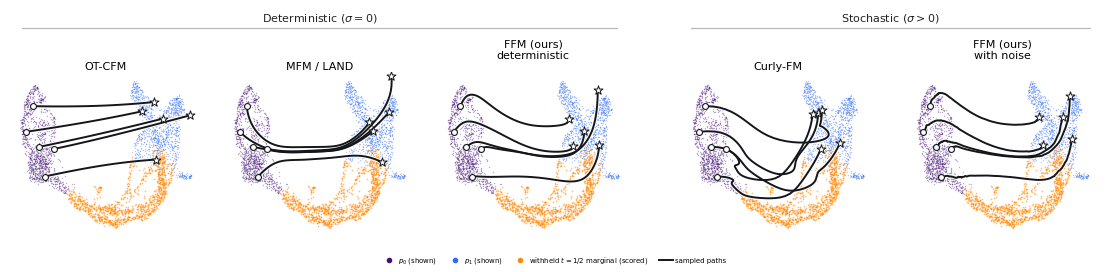

In [13]:
pf = nbfig.sheet_primitives()

FIG_LABELS = {**{nm: nm for nm in BASELINES},
              FFM_DET: two_line(QUAL_DET, ours=True),
              FFM_SDE: two_line(QUAL_NOISY, ours=True)}
FIG_BLOCKS = [(r"Deterministic ($\sigma = 0$)", ["OT-CFM", "MFM / LAND", FFM_DET]),
              (r"Stochastic ($\sigma > 0$)", ["Curly-FM", FFM_SDE])]

_cloud = CLOUDS[UMAP_DIM]
_U = _cloud.umap
_mu, _sd = _U.mean(axis=0), _U.std(axis=0)
_lo, _hi = _U.min(axis=0), _U.max(axis=0)
_pad = 0.06 * (_hi - _lo)

_traj = {nm: RUNS[UMAP_DIM][(nm, cfg.seeds[0])]["traj"] * _sd + _mu for nm in REPORTED}
_cols = pf._lateral_starts(_traj[FFM_DET][0], 5)

bg = nbfig.BlockGrid([(h, [(FIG_LABELS[nm], _traj[nm][:, _cols]) for nm in arms])
                      for h, arms in FIG_BLOCKS],
                     row_ratios=(1.0,), height=2.6, heading_fs=cfg.fs_heading)

for bi, (_h, cols) in enumerate(bg.blocks):
    for k, (label, tr) in enumerate(cols):
        ax = bg.ax(1, bi, k)
        for b, colour in ((TRAIN_BINS[0], REG[SOURCE]), (TRAIN_BINS[1], REG[TARGET])):
            m = _cloud.marginal(b)
            ax.scatter(_U[m, 0], _U[m, 1], s=1.0, lw=0, c=colour, alpha=0.35)
        m = _cloud.target_test
        ax.scatter(_U[m, 0], _U[m, 1], s=1.4, lw=0, c=REG[GAP], alpha=0.55)
        pf._draw_paths(ax, tr, three_d=False)
        ax.set_xlim(_lo[0] - _pad[0], _hi[0] + _pad[0])
        ax.set_ylim(_lo[1] - _pad[1], _hi[1] + _pad[1])
        ax.set_xticks([]); ax.set_yticks([])
        for side in ax.spines.values():
            side.set_visible(False)
        ax.set_title(label, fontsize=cfg.fs_heading, linespacing=1.1,
                     pad=2 + cfg.fs_heading * label.count("\n"))

bg.legend([plt.Line2D([], [], ls="", marker="o", ms=3, color=c, label=t)
           for c, t in ((REG[SOURCE], "$p_0$ (shown)"), (REG[TARGET], "$p_1$ (shown)"),
                        (REG[GAP], "withheld $t = 1/2$ marginal (scored)"))]
          + [plt.Line2D([], [], lw=1.4, color=pf._PATH_INK, label="sampled paths")],
          fontsize=cfg.fs_legend)
bg.save(pathlib.Path(figure_dir(cfg.smoke)) / "pancreas_paths")
plt.show()


## Band access

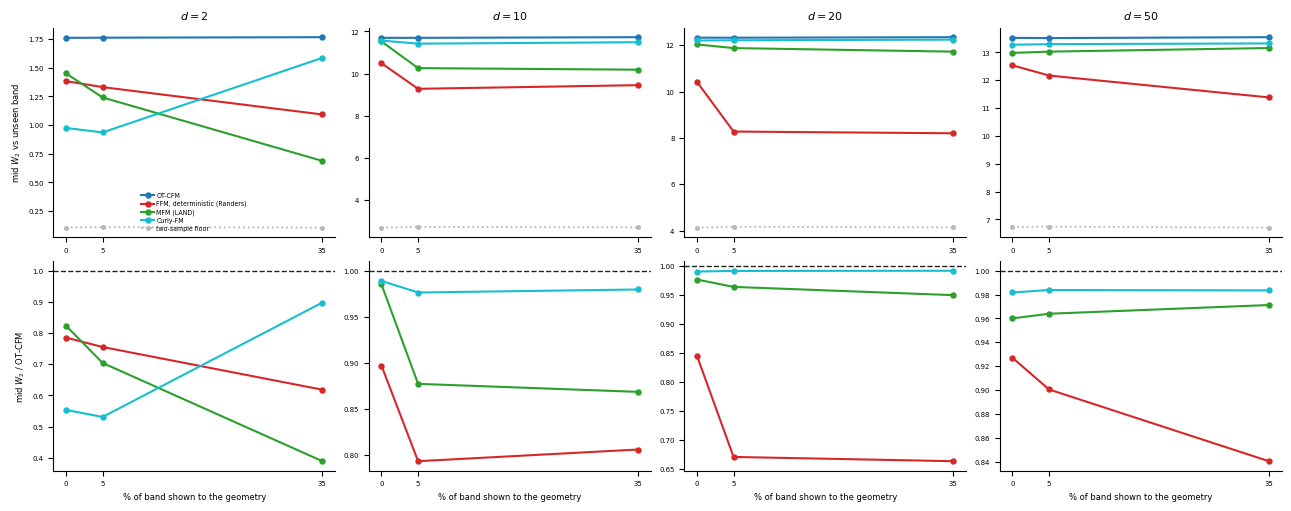


===== d = 2   n seeds = 3 =====
                                 0%            5%           35%       
                               mean     sd   mean     sd   mean     sd
OT-CFM                       1.7607 0.0262 1.7622 0.0392 1.7666 0.0297
FFM, deterministic (Randers) 1.3833 0.1410 1.3313 0.0627 1.0927 0.2477
MFM (LAND)                   1.4506 0.0025 1.2412 0.5283 0.6878 0.0378
Curly-FM                     0.9751 0.1704 0.9360 0.1045 1.5865 0.1369
two-sample floor             0.1072    NaN 0.1113    NaN 0.1061    NaN

===== d = 10   n seeds = 3 =====
                                  0%             5%            35%       
                                mean     sd    mean     sd    mean     sd
OT-CFM                       11.6958 0.1300 11.6954 0.1177 11.7261 0.0721
FFM, deterministic (Randers) 10.4924 0.3776  9.2784 0.0900  9.4515 0.1625
MFM (LAND)                   11.5233 0.0517 10.2600 0.8106 10.1850 0.1500
Curly-FM                     11.5671 0.3252 11.4191 0.1533 11.4878

In [14]:
import json

from scripts.core.labels import ARM_COLOURS, ARM_LABELS

BAND_DIR = pathlib.Path(os.environ.get("NB_BAND_DIR",
                                       PUBLIC / "data" / "band"))
BAND_ARMS = ("cfm", "ffm", "mfm_land", "curly")
BAND_REF = "held"

BAND = {}
for _p in sorted(BAND_DIR.glob("band_d*_f*.json")):
    _r = json.loads(_p.read_text())
    BAND[(int(_r["dim"]), float(_r["frac"]))] = _r

if not BAND:
    print(f"no band-access records under {BAND_DIR}")
else:
    _dims = sorted({d for d, _ in BAND})
    _fracs = sorted({f for _, f in BAND})
    _vals = lambda d, f, a: np.array(
        [_m[BAND_REF]["W2"] for _m in BAND[(d, f)]["arms"][a].values()], dtype=float)
    _mean = lambda d, f, a: float(_vals(d, f, a).mean())
    _sd = lambda d, f, a: sd_of(_vals(d, f, a))
    _floor_of = lambda d, f: float(np.mean(
        [_m["floors"][BAND_REF]["W2"] for _m in BAND[(d, f)]["arms"]["cfm"].values()]))

    fig, axes = plt.subplots(2, len(_dims), figsize=(3.2 * len(_dims), 5.0),
                             constrained_layout=True, squeeze=False)
    for _j, _d in enumerate(_dims):
        _have = [f for f in _fracs if (_d, f) in BAND]
        _x = [100.0 * f for f in _have]
        _y = {a: np.array([_mean(_d, f, a) for f in _have]) for a in BAND_ARMS}
        _top, _bot = axes[0][_j], axes[1][_j]

        for _a in BAND_ARMS:
            _top.plot(_x, _y[_a], marker="o", ms=3.6, lw=1.5,
                      color=ARM_COLOURS[_a], label=ARM_LABELS[_a])
        _top.plot(_x, [_floor_of(_d, f) for f in _have], ls=":", lw=1.3,
                  color=nbfig.FAINT, marker="o", ms=2.6, label="two-sample floor")
        _top.set_title(f"$d = {_d}$", fontsize=cfg.fs_heading)

        for _a in ("ffm", "mfm_land", "curly"):
            _bot.plot(_x, _y[_a] / _y["cfm"], marker="o", ms=3.6, lw=1.5,
                      color=ARM_COLOURS[_a])
        _bot.axhline(1.0, ls="--", lw=1.0, color=nbfig.INK, zorder=0)
        _bot.set_xlabel("% of band shown to the geometry", fontsize=cfg.fs_legend + 1)

        for _ax in (_top, _bot):
            _ax.set_xticks(_x)
            _ax.set_xticklabels([f"{v:g}" for v in _x])
            _ax.tick_params(labelsize=cfg.fs_legend)
            for _side in ("top", "right"):
                _ax.spines[_side].set_visible(False)

    axes[0][0].set_ylabel(r"mid $W_2$ vs unseen band", fontsize=cfg.fs_legend + 1)
    axes[1][0].set_ylabel(r"mid $W_2$ / OT-CFM", fontsize=cfg.fs_legend + 1)
    axes[0][0].legend(fontsize=cfg.fs_legend - 0.5, loc="best", frameon=False,
                      handletextpad=0.4, labelspacing=0.3)
    plt.show()

    for _d in _dims:
        _have = [f for f in _fracs if (_d, f) in BAND]
        _cols = {}
        for _fr in _have:
            _k = f"{100 * _fr:g}%"
            _cols[(_k, "mean")] = ({ARM_LABELS[a]: _mean(_d, _fr, a) for a in BAND_ARMS}
                                   | {"two-sample floor": _floor_of(_d, _fr)})
            _cols[(_k, "sd")] = {ARM_LABELS[a]: _sd(_d, _fr, a) for a in BAND_ARMS}
        print(f"\n===== d = {_d}   n seeds = "
              f"{len(BAND[(_d, _have[0])]['arms'][BAND_ARMS[0]])} =====")
        print(pd.DataFrame(_cols).to_string(float_format="%.4f"))


## Matched-information ablations

In [15]:
from scripts.experiments.matched import pancreas as matched

MATCHED_GONE = matched.missing()
if MATCHED_GONE:
    MATCHED = matched.ensure(cfg)
else:
    MATCHED = matched.load_records(matched.ROOT, keys=(matched.KEY,))

MATCHED_SUM = matched.frames(MATCHED)[0]
print(f"===== Pancreas, d = {next(iter(MATCHED.values()))['diag']['d']}")
print(MATCHED_SUM.round(4).to_string())


===== Pancreas, d = 20
                                                     mid W2  mid sd  end W2  end sd  runtime s  n seeds
coupling arm                                                                                           
common   Graph-drift FM (control)                   11.9409  0.1110  5.2511  0.0883     106.82        5
         Anisotropic fixed-time FM (control)        11.5712  0.0880  5.1742  0.1735     110.24        5
         Second-moment-only FFM (m = 0)             11.5424  0.1226  5.1995  0.1796     109.30        5
         FFM, Eq. (12) (ours)                       10.3967  0.1371  5.2078  0.1968     112.28        5
         FFM, one-form deleted (existing ablation)  11.1740  0.0759  5.1892  0.1201     111.12        5
specific Graph-drift FM (control)                   11.9223  0.0909  5.1626  0.1484     107.36        5
         Anisotropic fixed-time FM (control)        11.4344  0.1067  5.2180  0.1669     114.46        5
         Second-moment-only FFM (m = 0)  

In [16]:
from scripts.experiments.pancreas import noise as noise_ab

NOISE = noise_ab.ensure(cfg, TUNED[noise_ab.DIM])
for _f in noise_ab.frames(NOISE):
    print(_f.round(4).to_string())
    print()


path covariance M_t = C_rho                                            I                                    
                      sigma    mid W2  mid sd   end W2   end sd    sigma    mid W2  mid sd    end W2  end sd
width_mult                                                                                                  
0.003                0.0207   10.4874  0.0419   5.2457   0.2301   0.0167   10.4414  0.1439    5.2980  0.1595
0.010                0.0691   10.4940  0.1123   5.5062   0.4344   0.0558   10.5187  0.1591    5.2420  0.2684
0.030                0.2072   10.4873  0.0919   5.3305   0.1619   0.1673   10.4245  0.1359    5.3180  0.1351
0.100                0.6908   10.3694  0.0987   5.0662   0.3449   0.5576   10.3446  0.1299    5.1521  0.1702
0.300                2.0723   10.4630  0.2142   5.3692   0.1590   1.6727   10.4149  0.1922    5.2433  0.2451
1.000                6.9076   14.0089  0.0636   7.6047   0.3015   5.5757   13.8565  0.1498    7.3363  0.1651
3.000              

In [17]:
from scripts.experiments.pancreas import review as rv

REVIEW = rv.ensure(cfg, TUNED, DIMS_RUN)
print(rv.header(REVIEW))

2059/2059 runs, 24 support records, Tesla V100-SXM2-32GB


In [18]:
rv.show(rv.frame_seeds(REVIEW), rv.frame_restarts(REVIEW), rv.frame_hardware(REVIEW))

[scvelo_data] loading cache data/pancreas_cache/pancreas_d50_vw0.8_dynamical.npz


                                  n    mean      sd    q2.5  median   q97.5  seeds 0-2  pct among 3-seed means  P(FFM run wins)
d = 2 seed pool                                                                                                                
FFM (shipped)                  32.0  1.4541  0.2146  1.0384  1.5200  1.7633     1.6692                 98.2056              NaN
FFM, default point             20.0  1.4623  0.1089  1.2129  1.4839  1.5864     1.5005                 73.7719           0.4578
FFM, one-form off              20.0  1.7910  0.0868  1.6277  1.7971  1.9355     1.8245                 76.0526           0.9547
FFM, no grad clip              20.0  1.3797  0.1796  1.0761  1.4004  1.6541     1.3749                 47.2807           0.3812
FFM, graph-denoised moments    20.0  1.0559  0.0916  0.8950  1.0442  1.2226     0.9854                  7.8070           0.0609
FFM, global window, n_eff 100  20.0  0.9434  0.1237  0.7704  0.9303  1.1816     0.9955                 7

In [19]:
rv.show(rv.frame_chaos(REVIEW))

                                seeds   mid W2  seed sd  seed sd n  chaos %  within / seed sd  rerun |dW2|
d  1e-7 perturbation                                                                                      
2  FFM (shipped)                  3.0   1.6692   0.2146       32.0   8.6718            0.6295          0.0
   FFM, default point             3.0   1.5005   0.1089       20.0  13.1208            1.7146          NaN
   FFM, one-form off              3.0   1.8245   0.0868       20.0   3.2963            0.6761          NaN
   FFM, no grad clip              3.0   1.3749   0.1796       20.0  13.3832            1.0169          NaN
   FFM, graph-denoised moments    3.0   0.9854   0.0916       20.0   7.4898            0.8653          NaN
   FFM, n_eff = 100 window        3.0   2.3225   0.1832        3.0   4.6751            0.5880          NaN
   FFM, off-support barrier       3.0   1.2724   0.3798       20.0  13.7199            0.4712          NaN
   MFM / LAND                     3.0

In [20]:
rv.show(rv.frame_arms(REVIEW), rv.frame_support(REVIEW))

                                        n     mid W2     pop sd    vs FFM %        end W2  window W2    bend  F-length / chord
d  seeds 0-2                                                                                                                  
2  FFM (shipped)                      3.0     1.6692     0.0154      0.0000  3.283000e-01     1.6393  0.3153            0.8677
   FFM, default point                 3.0     1.5005     0.1048    -10.1096  2.850000e-01     1.5382  0.2511            0.8698
   FFM, one-form off                  3.0     1.8245     0.0997      9.3018  2.030000e-01     1.8553  0.0710            1.0122
   FFM, no grad clip                  3.0     1.3749     0.2151    -17.6321  2.158000e-01     1.4008  0.3243            0.8753
   FFM, graph-denoised moments        3.0     0.9854     0.0457    -40.9665  4.042000e-01     1.0264  0.5236            0.9395
   FFM, n_eff = 100 window            3.0     2.3225     0.1496     39.1361  1.149900e+00     2.3013  0.9752   

In [21]:
rv.show(rv.frame_band(REVIEW))

                                     0%       5%      10%      20%      35%      45%  0% pop sd  5% pop sd  10% pop sd  20% pop sd  35% pop sd  45% pop sd  5% vs 0%  10% vs 0%  20% vs 0%  35% vs 0%  45% vs 0%
d  band shown, one scored half                                                                                                                                                                                  
2  FFM (shipped)                 1.6748   1.2994   1.2705   1.4427   1.5280   1.5463     0.0175     0.1721      0.1271      0.4235      0.0867      0.0010  -22.4139   -24.1425   -13.8616    -8.7670    -7.6735
   OT-CFM                        1.8046   1.8046   1.8046   1.8046   1.8046   1.8046     0.0200     0.0200      0.0200      0.0200      0.0200      0.0200    0.0000     0.0000     0.0000     0.0000     0.0000
   MFM / LAND                    1.4832   0.9903   0.6378   1.0035   0.6256   0.6049     0.0067     0.4468      0.0270      0.0308      0.0227      0.0110  -33.2282

In [22]:
rv.show(rv.frame_round4(REVIEW))

                                           0%       5%      10%      20%        35%      45%  45% vs 0%  diverged
d  untuned, band shown                                                                                           
2  FFM, default point                  1.5553   1.3567   1.3564   1.3593     1.4018   1.5698     0.9297       0.0
   OT-CFM                              1.8231   1.8231   1.8231   1.8231     1.8231   1.8231     0.0000       0.0
   MFM / LAND, untuned                 1.4834   1.4415   0.6629   0.9953     0.6012   0.6111   -58.8019       0.0
   Curly-FM, untuned (alpha 0.01)      1.2768   0.8126   0.3774   0.6452     0.5179   0.5647   -55.7706       0.0
   FFM, default point, uniform kNN P   1.8453   1.8697   2.0106   1.9840     1.9610   1.9381     5.0256       0.0
10 FFM, default point                 11.1957   9.3593   9.0026   9.6786     9.9999   9.7908   -12.5487       0.0
   OT-CFM                             11.7164  11.7164  11.7164  11.7164    11.7164  11.

In [23]:
rv.show(*rv.frame_search(REVIEW), rv.frame_fresh(REVIEW))

                                  rho_mult  lam_mult  objective  objective, 4 seeds  reported W2  reported rank
d = 2 search, 80 cells x 4 seeds                                                                               
picked on seed 0                     0.001     0.001     0.4931              0.9776       1.5087             41
picked on seed 1                     3.000     0.300     0.6863              0.8359       1.5017             40
picked on seed 2                     1.000     0.030     0.6625              0.7754       1.1852              1
picked on seed 3                     3.000     0.030     0.5592              0.7833       1.4561             25
picked on 4-seed mean                1.000     0.030     0.7754              0.7754       1.1852              1
notebook TUNED                       0.100     0.100        NaN              0.9523       1.5383             53
library default                      1.000     0.300        NaN              0.8938       1.5200        